Processing Oregon  (tile 50N_130W) …
  emis: 94,037 ha  |  1,451,994 MgCO2/yr
  remv: 149,243 ha  |  1,741,821 MgCO2/yr
Processing Pará  (tile 00N_060W) …
  emis: 107,916 ha  |  517,256 MgCO2/yr
  remv: 129,578 ha  |  365,497 MgCO2/yr
Processing Québec  (tile 50N_080W) …
  emis: 71,440 ha  |  1,002,190 MgCO2/yr
  remv: 108,916 ha  |  389,736 MgCO2/yr
Processing Kalimantan Tengah  (tile 00N_110E) …
  emis: 134,118 ha  |  2,272,199 MgCO2/yr
  remv: 158,022 ha  |  2,253,777 MgCO2/yr
Done


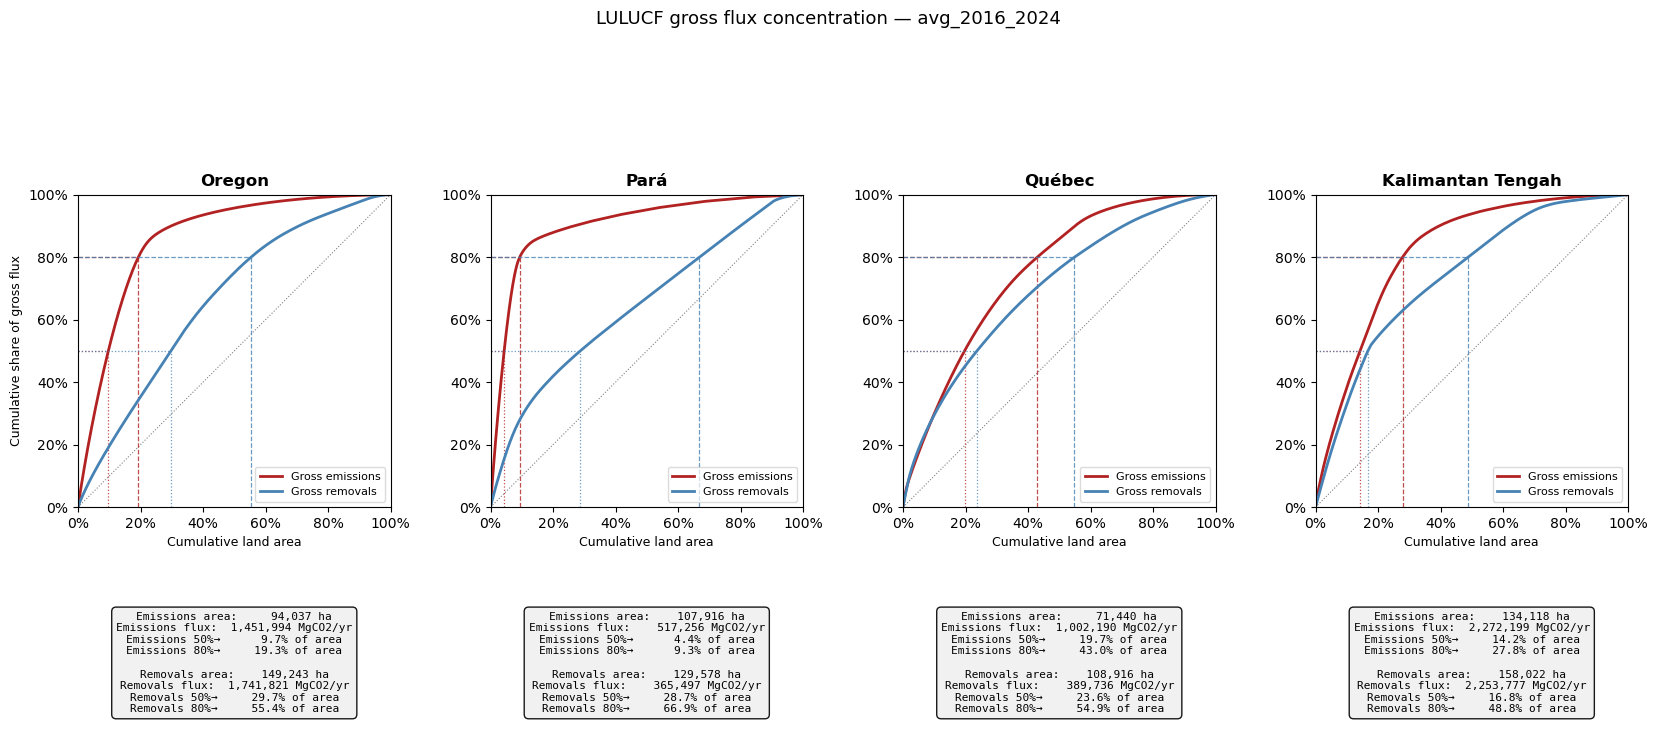

In [4]:
### Lorenz curves for local portrait areas
### Clips 10×10-deg per-ha LULUCF GeoTIFs to each shapefile feature, uses exact (sorted) curves
### Panel order: shapefile feature order; title: 'state' field

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.mask import mask as rio_mask

# ── Config ────────────────────────────────────────────────────────────────────
SHAPEFILE_PATH = "/mnt/c/GIS/AFOLU_flux_model/LULUCF/local_portrait_areas/20260619_v2/net_flux_aoi_20260619_161520.shp"

PERIOD   = "avg_2016_2024"
BASE     = "s3://gfw2-data/climate/AFOLU_flux_model/LULUCF/outputs_LULUCF_totals/LULUCF_version_1_0_0_standard__global__veg_v1_0_5__org_soil_v1_0_1__min_soil_v1_0_1"
EMIS_DIR = f"{BASE}/LULUCF_gross_emissions__all_C_pools__all_gases__MgCO2e/annual_intervals/avg_2016_2024/_ha_yr/40000_pixels/20260614"
REMV_DIR = f"{BASE}/LULUCF_gross_removals__all_C_pools__MgCO2/annual_intervals/avg_2016_2024/_ha_yr/40000_pixels/20260614"
EMIS_VAR = f"LULUCF_gross_emissions__all_C_pools__all_gases__MgCO2e_ha_yr_{PERIOD}"
REMV_VAR = f"LULUCF_gross_removals__all_C_pools__MgCO2_ha_yr_{PERIOD}"

EMIS_COLOR = 'firebrick'
REMV_COLOR = 'steelblue'


# ── Helpers ───────────────────────────────────────────────────────────────────
def tile_id_10deg(lon, lat):
    """10×10-degree tile ID (NW-corner convention): top and left edges of tile."""
    nw_lat = int(np.ceil(lat / 10) * 10)
    w_lon  = int(np.floor(lon / 10) * 10)
    lat_str = f"{abs(nw_lat):02d}{'N' if nw_lat >= 0 else 'S'}"
    lon_str = f"{abs(w_lon):03d}{'E' if w_lon >= 0 else 'W'}"
    return f"{lat_str}_{lon_str}"


def lorenz_exact(intensity, area):
    """Exact Lorenz curve: sort descending by intensity, cumsum area and flux."""
    order = np.argsort(intensity)[::-1]
    cumA  = np.concatenate([[0.0], np.cumsum(area[order])])
    cumF  = np.concatenate([[0.0], np.cumsum((intensity * area)[order])])
    return cumA / cumA[-1], cumF / cumF[-1]


def read_clip(s3_path, geom):
    """
    Open raster from S3, clip to geom (shapely, WGS84).
    Returns dict with 'intensity' and 'area' (ha) arrays, or None on failure.
    """
    try:
        with rasterio.open(s3_path) as src:
            data, t = rio_mask(src, [geom], crop=True, nodata=src.nodata)
            data    = data[0].astype(np.float64)
            nodata  = src.nodata
    except Exception as e:
        print(f"  Could not open {s3_path}: {e}")
        return None

    lats = np.linspace(t.f + t.e * 0.5, t.f + t.e * (data.shape[0] - 0.5), data.shape[0])
    pxha = (6371.0**2 * abs(np.deg2rad(t.e)) * abs(np.deg2rad(t.a))
             * np.cos(np.deg2rad(lats)) * 100)
    pxha = np.broadcast_to(pxha[:, None], data.shape).copy()

    valid = np.isfinite(data) & (data != 0)
    if nodata is not None:
        valid &= (data != nodata)
    if not valid.any():
        print(f"  No valid pixels in {s3_path}")
        return None
    return {'intensity': np.abs(data[valid]), 'area': pxha[valid]}


# ── Process shapefile ─────────────────────────────────────────────────────────
gdf = gpd.read_file(SHAPEFILE_PATH, encoding='latin-1')
# Reproject to WGS84 for masking against geographic rasters
gdf_4326 = gdf.to_crs('EPSG:4326') if gdf.crs and gdf.crs.to_epsg() != 4326 else gdf

panels = []
for _, row in gdf_4326.iterrows():
    label = str(row['state']).strip()
    lon, lat = float(row['lon']), float(row['lat'])   # explicit WGS84 fields from DBF
    tid  = tile_id_10deg(lon, lat)
    geom = row.geometry
    # A 20 km radius circle is ~0.2° wide at these latitudes; straddling a
    # 10° tile boundary is extremely unlikely but not checked here.

    print(f"Processing {label}  (tile {tid}) …")
    emis_arr = read_clip(f"{EMIS_DIR}/{tid}__{EMIS_VAR}.tif", geom)
    remv_arr = read_clip(f"{REMV_DIR}/{tid}__{REMV_VAR}.tif", geom)

    p = {'label': label}
    for key, arr in [('emis', emis_arr), ('remv', remv_arr)]:
        if arr is not None:
            p[f'{key}_x'], p[f'{key}_y'] = lorenz_exact(arr['intensity'], arr['area'])
            p[f'{key}_ha'] = arr['area'].sum()
            p[f'{key}_Mg'] = (arr['intensity'] * arr['area']).sum()
            print(f"  {key}: {p[f'{key}_ha']:,.0f} ha  |  {p[f'{key}_Mg']:,.0f} MgCO2/yr")
        else:
            p[f'{key}_x'] = p[f'{key}_y'] = p[f'{key}_ha'] = p[f'{key}_Mg'] = None
    panels.append(p)

print("Done")


# ── Figure ────────────────────────────────────────────────────────────────────
pct_fmt = matplotlib.ticker.FuncFormatter(lambda v, _: f'{100*v:.0f}%')

fig = plt.figure(figsize=(20, 8))
gs  = fig.add_gridspec(2, 4, height_ratios=[4, 1], hspace=0.08, wspace=0.32)
plot_axes = [fig.add_subplot(gs[0, i]) for i in range(4)]
text_axes = [fig.add_subplot(gs[1, i]) for i in range(4)]
for ax in text_axes:
    ax.axis('off')

for col, (ax, p) in enumerate(zip(plot_axes, panels)):
    ax.plot([0, 1], [0, 1], color='gray', lw=0.8, ls=':', zorder=0)
    ax.set_title(p['label'], fontsize=12, fontweight='bold', pad=6)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_box_aspect(1)
    ax.xaxis.set_major_formatter(pct_fmt)
    ax.yaxis.set_major_formatter(pct_fmt)
    ax.set_xlabel('Cumulative land area', fontsize=9)
    if col == 0:
        ax.set_ylabel('Cumulative share of gross flux', fontsize=9)

    diag_lines = []
    for key, color, lbl in [('emis', EMIS_COLOR, 'Emissions'), ('remv', REMV_COLOR, 'Removals')]:
        if p[f'{key}_x'] is None:
            diag_lines.append(f"{lbl}: no data")
            continue
        x, y = p[f'{key}_x'], p[f'{key}_y']
        ax.plot(x, y, color=color, lw=2,
                label='Gross emissions' if key == 'emis' else 'Gross removals')
        for target, ls in [(0.50, ':'), (0.80, '--')]:
            x_at = np.interp(target, y, x)
            ax.axvline(x=x_at, ymin=0, ymax=target, color=color, lw=0.9, ls=ls, alpha=0.8)
            ax.axhline(y=target, xmin=0, xmax=x_at,  color=color, lw=0.9, ls=ls, alpha=0.8)
        x50 = np.interp(0.50, y, x)
        x80 = np.interp(0.80, y, x)
        diag_lines += [
            f"{lbl} area: {p[f'{key}_ha']:>10,.0f} ha",
            f"{lbl} flux: {p[f'{key}_Mg']:>10,.0f} MgCO2/yr",
            f"{lbl} 50%→ {100*x50:>8.1f}% of area",
            f"{lbl} 80%→ {100*x80:>8.1f}% of area",
            "",
        ]

    ax.legend(loc='lower right', fontsize=8, framealpha=0.7)
    text_axes[col].text(
        0.5, 1.0, "\n".join(diag_lines).rstrip(),
        transform=text_axes[col].transAxes,
        ha='center', va='top', fontsize=8, family='monospace',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f0f0f0', alpha=0.9),
    )

fig.suptitle(f'LULUCF gross flux concentration — {PERIOD}', fontsize=13, y=1.01)
plt.show()

# ── Save (uncomment to use) ───────────────────────────────────────────────────
# out_path = ("/mnt/c/GIS/AFOLU_flux_model/LULUCF/local_portrait_areas/"
#             "20260618_v1/lorenz_portrait_areas.png")
# fig.savefig(out_path, dpi=150, bbox_inches='tight')
# print(f"Saved: {out_path}")